# Task 10.2 C
### Name: Nay Tun
### Student Id: 225110052

# 1. Load the MINIST Digit dataset, show the size of the training and test set.

In [11]:
import tensorflow as tf
from tensorflow import keras
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [12]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [13]:
print (f"Size of test set: {len(x_test)}")
print (f"Size of train set: {len(x_train)}")

Size of test set: 10000
Size of train set: 60000


### Sizes
|Sets|Size|
|------|------|
|Train|60000 rows|
|Test|10000 rows|

#


# 2. Develop a one hidden layer multi-layer perceptron model on the above training data, report the accuracy of the model.

### Reashape from 2D 28x28 to 1D and normalize

In [14]:
x_train_1d = x_train.reshape(x_train.shape[0],-1) / 255
x_test_1d = x_test.reshape(x_test.shape[0],-1) / 255


In [15]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=[100,]
    ,random_state=1
    ,max_iter=300
)

mlp_clf.fit(x_train_1d, y_train)
pred = mlp_clf.predict(x_test_1d)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Overall accuracy is 0.98 or the 10,000 dataset with one hidden layer.
### The worse peforming class is, digits 8 and 9 because of their similar shapes.
### the best ones are 0 and 1 due to distinct shape.  0 is distince from 1
### Overall it generalizes well accross all 10 classes with balanced precision and recall.

#

# 3. From question 2, set the number of hidden layers of the MLP model as [2,4,6,8,10], set the hidden layer size as 100, show the accuracies on the test set. 

In [16]:
neurons = 100
layers = [2,4,6,8,10]
scores = []
for l in layers:
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=(neurons) * l
        ,random_state=1
        ,max_iter=300
    )
    mlp_clf.fit(x_train_1d, y_train)
    score = mlp_clf.score(x_test_1d, y_test)
    scores.append(score)
    print (f"Layer {l} score: {score}")




Layer 2 score: 0.9809
Layer 4 score: 0.983
Layer 6 score: 0.984
Layer 8 score: 0.9764
Layer 10 score: 0.9821


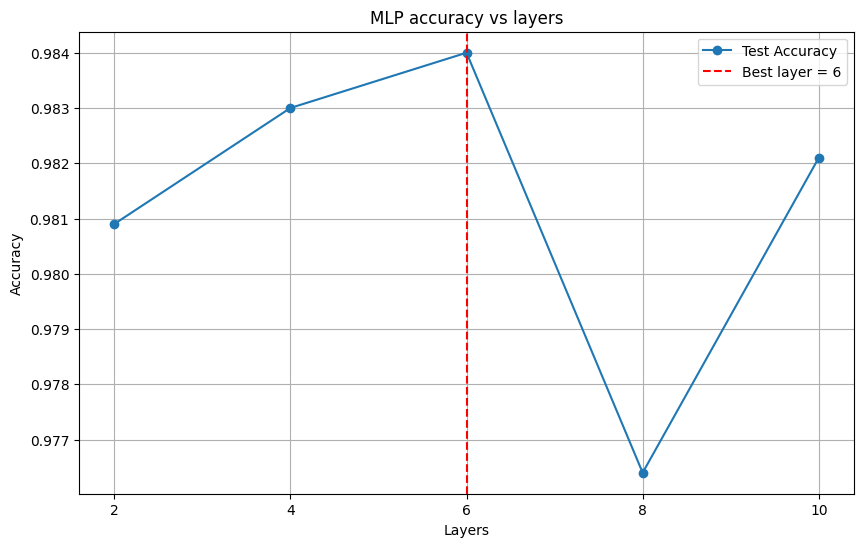

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(layers, scores, label='Test Accuracy', marker='o')
plt.xlabel('Layers')
plt.ylabel('Accuracy')
plt.title('MLP accuracy vs layers')
plt.legend()
plt.xticks(layers)
plt.grid(True)

# Mark best layer
best_layer = layers[scores.index(max(scores))]
plt.axvline(x=best_layer, color='red', linestyle='--', label=f'Best layer = {best_layer}')
plt.legend()
plt.show()

# Layer 6 seems to have the best accuracy with 0.984

# 

# 4. From question 2, for the hidden layer set the hidden layer size as [50, 100, 150, 200], show the accuracies on the test set. 

In [18]:
layer_sizes = [50, 100, 150, 200]
scores = []
for neurons in layer_sizes:
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=(neurons) * 1
        ,random_state=1
        ,max_iter=300
    )
    mlp_clf.fit(x_train_1d, y_train)
    score = mlp_clf.score(x_test_1d, y_test)
    scores.append(score)
    print (f"Layer size {neurons} score: {score}")


Layer size 50 score: 0.9715
Layer size 100 score: 0.9791
Layer size 150 score: 0.9787
Layer size 200 score: 0.9809


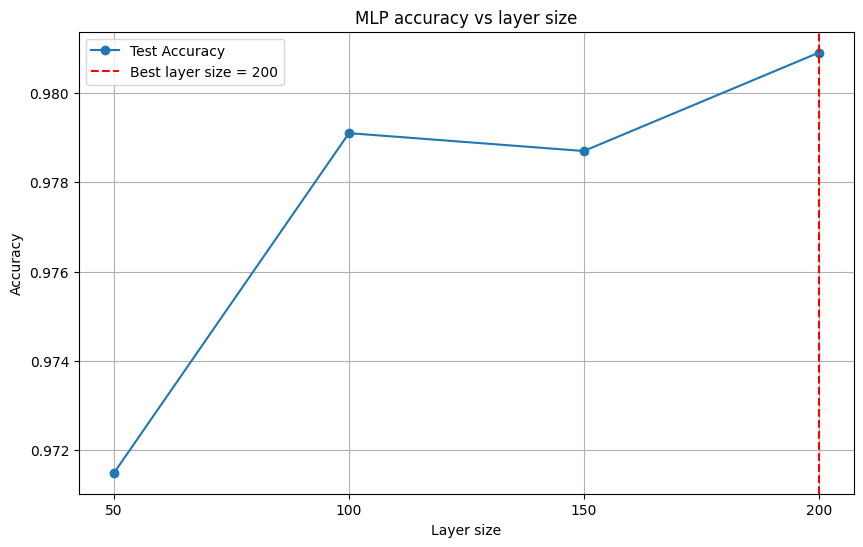

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(layer_sizes, scores, label='Test Accuracy', marker='o')
plt.xlabel('Layer size')
plt.ylabel('Accuracy')
plt.title('MLP accuracy vs layer size')
plt.legend()
plt.xticks(layer_sizes)
plt.grid(True)

# Mark best layer
best_layer_size = layer_sizes[scores.index(max(scores))]
plt.axvline(x=best_layer_size, color='red', linestyle='--', label=f'Best layer size = {best_layer_size}')
plt.legend()
plt.show()

#

# 5. Based on question 3 and 4, explain the key findings. 

### Accuracy increases as more layers are added but eventually the accuracy dips.  As more layer are added the network can learn more complex patterners.  However accuracy will eventuall dips due to the vanishing gradient problem.  Gradients becomes too small to be updated effectively as more layers makes the training unstable.
### Accuracy is best at the largest layer size.  I added more size all the way up to 700 and it seem to increase as size increase but eventually dips and then comes back up again. More neurons give the model greater capacity to learn features.  The dip at mid range suggest overfitting as the model memorises training data.  But at very large neurons, the accuracy improves again maybe due to the model having enough redundancy to generalise again.
### Vanishing gradient - too many layers
### Overfitting - too many neurons

# 

# 6. As the deep neural network size is increased, double descent refers to the phenomenon in which the model performance initially improves, then gets worse, and ultimately improves again.  Create  two-layer  fully  connected  neural  networks, increase the network size by setting bigger hidden layer sizes, try to reproduce the double descent risk curve with the above MINIST dataset. Justify your experiment result.

In [25]:
layer_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
train_errors = []
test_errors = []
for neurons in layer_sizes:
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=(neurons) * 2
        ,random_state=1
        ,max_iter=500
    )
    mlp_clf.fit(x_train_1d, y_train)
    
    score = mlp_clf.score(x_train_1d, y_train)
    train_errors.append(1 - score)
    score = mlp_clf.score(x_test_1d, y_test)
    test_errors.append(1 - score)
    print (f"Layer size {neurons} score: {score}")


Layer size 50 score: 0.9791
Layer size 100 score: 0.9809
Layer size 150 score: 0.974
Layer size 200 score: 0.983
Layer size 250 score: 0.9844
Layer size 300 score: 0.984
Layer size 350 score: 0.9835
Layer size 400 score: 0.9764
Layer size 500 score: 0.9821
Layer size 600 score: 0.9848
Layer size 700 score: 0.9846


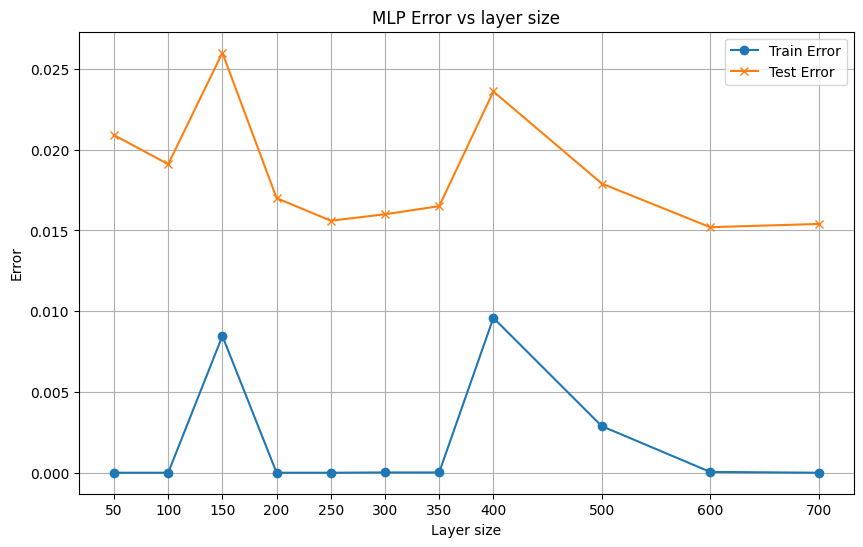

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(layer_sizes, train_errors, label='Train Error', marker='o')
plt.plot(layer_sizes, test_errors, label='Test Error', marker='x')
plt.xlabel('Layer size')
plt.ylabel('Error')
plt.title('MLP Error vs layer size')
plt.legend()
plt.xticks(layer_sizes)
plt.grid(True)

# Mark best layer
#best_layer_size = layer_sizes[scores.index(max(scores))]
#plt.axvline(x=best_layer_size, color='red', linestyle='--', label=f'Best layer size = {best_layer_size}')
plt.legend()
plt.show()

## The curve shows characteristics of double descent, the test error peaks around 150 neurons, partially recovers, peaks again at 400, then decreases as model size grows. Train error approaches zero at large sizes indicating the interpolation threshold has been crossed. However the pattern is noisy, maybe due to insufficient training iterations at larger layer sizes